# データサイエンス講座(統計編) 10〜17 多変数の記述統計学

In [1]:
# import time
import numpy as np

# from scipy import stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# from sklearn.preprocessing import StandardScaler
%matplotlib inline

## 10 絶対にわかる共分散

[絶対にわかる共分散【統計学入門⑩】 - 米国データサイエンティストのブログ](https://datawokagaku.com/covariance/)

- 分散共分散行列 (variance-covariance matrix)
	- `numpy.cov(m, y=None, bias=False, ddof=None)`: `m` と `y` は共分散を計算したいデータ（同じ型）、`bias`は不偏性の指定、更に `ddof` で `bias` の指定は上書きされる
	- `pandas.DataFrame.cov(ddof=1)`

In [2]:
weight = np.array([42, 46, 53, 56, 58, 61, 62, 63, 65, 67, 73])
height = np.array([138, 150, 152, 163, 164, 167, 165, 182, 180, 180, 183])

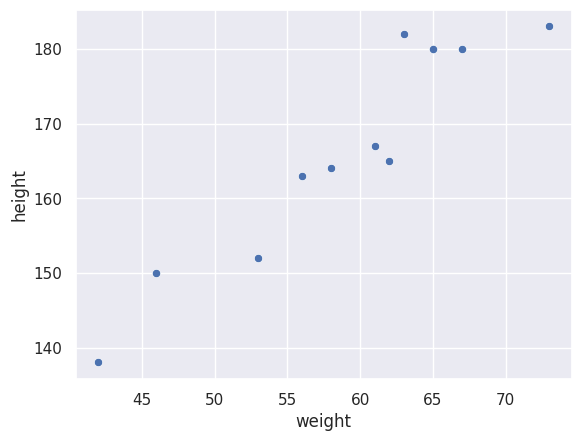

In [3]:
sns.set_theme()
fig, axes = plt.subplots()
sns.scatterplot(x=weight, y=height, ax=axes)
axes.set_xlabel("weight")
axes.set_ylabel("height")
plt.show()

### 共分散

In [4]:
def my_cov(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    return np.sum((x - np.mean(x)) * (y - np.mean(y))) / (len(x) - 1)

In [5]:
my_cov(weight, height)

np.float64(127.54545454545455)

### 分散共分散行列

In [6]:
X = np.column_stack((weight, height))
X

array([[ 42, 138],
       [ 46, 150],
       [ 53, 152],
       [ 56, 163],
       [ 58, 164],
       [ 61, 167],
       [ 62, 165],
       [ 63, 182],
       [ 65, 180],
       [ 67, 180],
       [ 73, 183]])

平均を求める

In [7]:
n = X.shape[0]
j = np.ones((1, n))
j

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

In [8]:
j @ X / n

array([[ 58.72727273, 165.81818182]])

In [9]:
np.mean(weight), np.mean(height)

(np.float64(58.72727272727273), np.float64(165.8181818181818))

In [10]:
n = X.shape[0]
J = np.ones((n, n))
J

array([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

In [11]:
J @ X / n

array([[ 58.72727273, 165.81818182],
       [ 58.72727273, 165.81818182],
       [ 58.72727273, 165.81818182],
       [ 58.72727273, 165.81818182],
       [ 58.72727273, 165.81818182],
       [ 58.72727273, 165.81818182],
       [ 58.72727273, 165.81818182],
       [ 58.72727273, 165.81818182],
       [ 58.72727273, 165.81818182],
       [ 58.72727273, 165.81818182],
       [ 58.72727273, 165.81818182]])

偏差の行列を求める

In [12]:
Xc = X - J @ X / n
Xc

array([[-16.72727273, -27.81818182],
       [-12.72727273, -15.81818182],
       [ -5.72727273, -13.81818182],
       [ -2.72727273,  -2.81818182],
       [ -0.72727273,  -1.81818182],
       [  2.27272727,   1.18181818],
       [  3.27272727,  -0.81818182],
       [  4.27272727,  16.18181818],
       [  6.27272727,  14.18181818],
       [  8.27272727,  14.18181818],
       [ 14.27272727,  17.18181818]])

**補足**: NumPyではブロードキャストが行われるため、実際には行ベクトル`j`をかけても同じ結果が得られる。こちらのほうが効率が良い。

In [13]:
X - j @ X / n

array([[-16.72727273, -27.81818182],
       [-12.72727273, -15.81818182],
       [ -5.72727273, -13.81818182],
       [ -2.72727273,  -2.81818182],
       [ -0.72727273,  -1.81818182],
       [  2.27272727,   1.18181818],
       [  3.27272727,  -0.81818182],
       [  4.27272727,  16.18181818],
       [  6.27272727,  14.18181818],
       [  8.27272727,  14.18181818],
       [ 14.27272727,  17.18181818]])

分散共分散行列を求める

In [14]:
Xc.T @ Xc / (n - 1)

array([[ 82.81818182, 127.54545455],
       [127.54545455, 218.76363636]])

In [15]:
def my_cov(*args: np.ndarray) -> np.ndarray:
    X = np.column_stack(args)
    n = X.shape[0]

    j = np.ones((1, n))
    # ブロードキャストされるので正方行列Jをかけた場合と同じ結果になる
    Xc = X - j @ X / n
    return Xc.T @ Xc / (n - 1)

In [16]:
my_cov(weight, height)

array([[ 82.81818182, 127.54545455],
       [127.54545455, 218.76363636]])

In [17]:
np.cov(weight, height)

array([[ 82.81818182, 127.54545455],
       [127.54545455, 218.76363636]])

In [18]:
np.cov(X.T)

array([[ 82.81818182, 127.54545455],
       [127.54545455, 218.76363636]])

In [19]:
np.cov(weight, height, bias=True)

array([[ 75.2892562 , 115.95041322],
       [115.95041322, 198.87603306]])

In [20]:
np.cov(weight, height, ddof=0)

array([[ 75.2892562 , 115.95041322],
       [115.95041322, 198.87603306]])

In [21]:
df = pd.DataFrame({"weight": weight, "height": height})
df

,weight,height
0,42,138
1,46,150
2,53,152
3,56,163
4,58,164
5,61,167
6,62,165
7,63,182
8,65,180
9,67,180


In [22]:
df.cov()

,weight,height
weight,82.818182,127.545455
height,127.545455,218.763636


## 11 相関係数をわかりやすく解説

[相関係数をわかりやすく解説【統計学入門11】 - 米国データサイエンティストのブログ](https://datawokagaku.com/correlation_coefficient/)

- **相関行列 (correlation matrix)**
    - `numpy.corrcoef(x, y=None)`
    - `pandas.DataFrame.corr()`
- **行列操作**
    - 行列の対角成分、対角行列: `numpy.diag(v, k=0)`
    - **ndarrayに次元を追加: `ndarray[:, np.newaxis]`**

### 相関係数

In [23]:
def my_corrcoef(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    cov_mat = np.cov(x, y)
    s_x_y = cov_mat[1, 0]
    s_x, s_y = np.sqrt(np.diag(cov_mat))
    return s_x_y / (s_x * s_y)

In [24]:
my_corrcoef(weight, height)

np.float64(0.9475771359123567)

### 相関行列

#### 実装1（行列の積）

In [25]:
def my_corrcoef(*args: np.ndarray) -> np.ndarray:
    X = np.column_stack(args)
    S = np.cov(X.T)

    D_inv_std = np.diag(np.diag(S) ** (-1 / 2))
    return D_inv_std @ S @ D_inv_std

In [26]:
my_corrcoef(weight, height)

array([[1.        , 0.94757714],
       [0.94757714, 1.        ]])

#### 実装2（np.newaxis + ブロードキャスト + アダマール積）

In [27]:
S = np.cov(weight, height)
S

array([[ 82.81818182, 127.54545455],
       [127.54545455, 218.76363636]])

In [28]:
inv_std = np.diag(S) ** (-1 / 2)
inv_std

array([0.10988468, 0.06761023])

In [29]:
inv_std[:, np.newaxis]

array([[0.10988468],
       [0.06761023]])

In [30]:
np.broadcast_to(inv_std[:, np.newaxis], S.shape)

array([[0.10988468, 0.10988468],
       [0.06761023, 0.06761023]])

In [31]:
np.broadcast_to(inv_std, S.shape)

array([[0.10988468, 0.06761023],
       [0.10988468, 0.06761023]])

In [32]:
inv_std[:, np.newaxis] * S * inv_std

array([[1.        , 0.94757714],
       [0.94757714, 1.        ]])

In [33]:
def my_corrcoef(*args: np.ndarray) -> np.ndarray:
    X = np.column_stack(args)
    S = np.cov(X.T)

    inv_std = np.diag(S) ** (-1 / 2)
    return inv_std[:, np.newaxis] * S * inv_std

In [34]:
my_corrcoef(weight, height)

array([[1.        , 0.94757714],
       [0.94757714, 1.        ]])

#### ライブラリを利用

In [35]:
np.corrcoef(weight, height)

array([[1.        , 0.94757714],
       [0.94757714, 1.        ]])

In [36]:
np.corrcoef(X.T)

array([[1.        , 0.94757714],
       [0.94757714, 1.        ]])

In [37]:
df.corr()

,weight,height
weight,1.000000,0.947577
height,0.947577,1.000000


<Axes: >

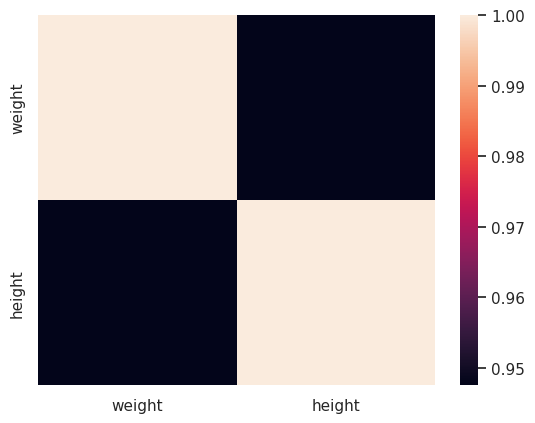

In [38]:
sns.heatmap(df.corr())

## 12 これだけは知っておいた方がいい相関係数のポイント3つ

[これだけは知っておいた方がいい相関係数のポイント3つ【統計学入門12】 - 米国データサイエンティストのブログ](https://datawokagaku.com/correlation_coefficient2/)

### 実験: 相関係数の強弱を確かめる

In [39]:
def generate_values(r=0.5, num=1000):
    rng = np.random.default_rng(1728)
    # 値
    a = rng.standard_normal(num)
    # 誤差項
    e1 = rng.standard_normal(num)
    e2 = rng.standard_normal(num)

    # 相関係数がrになるように変数x, yを作成
    if r < 0:
        r = -r
        x = -np.sqrt(r) * a - np.sqrt(1 - r) * e1
    else:
        x = np.sqrt(r) * a + np.sqrt(1 - r) * e1

    y = np.sqrt(r) * a + np.sqrt(1 - r) * e2

    actual_r = np.corrcoef(x, y)[0, 1]

    return x, y, actual_r

#### 相関係数 0.5

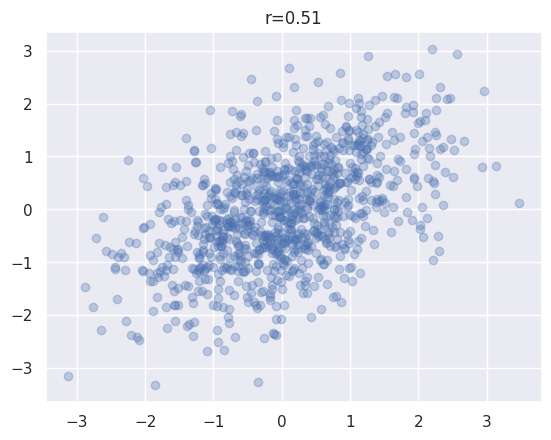

In [40]:
fig, axes = plt.subplots()
x, y, actual_r = generate_values()
axes.scatter(x, y, alpha=0.3)
axes.set_title(f"r={actual_r:0.2f}")
plt.show()

#### 相関係数の一覧表示

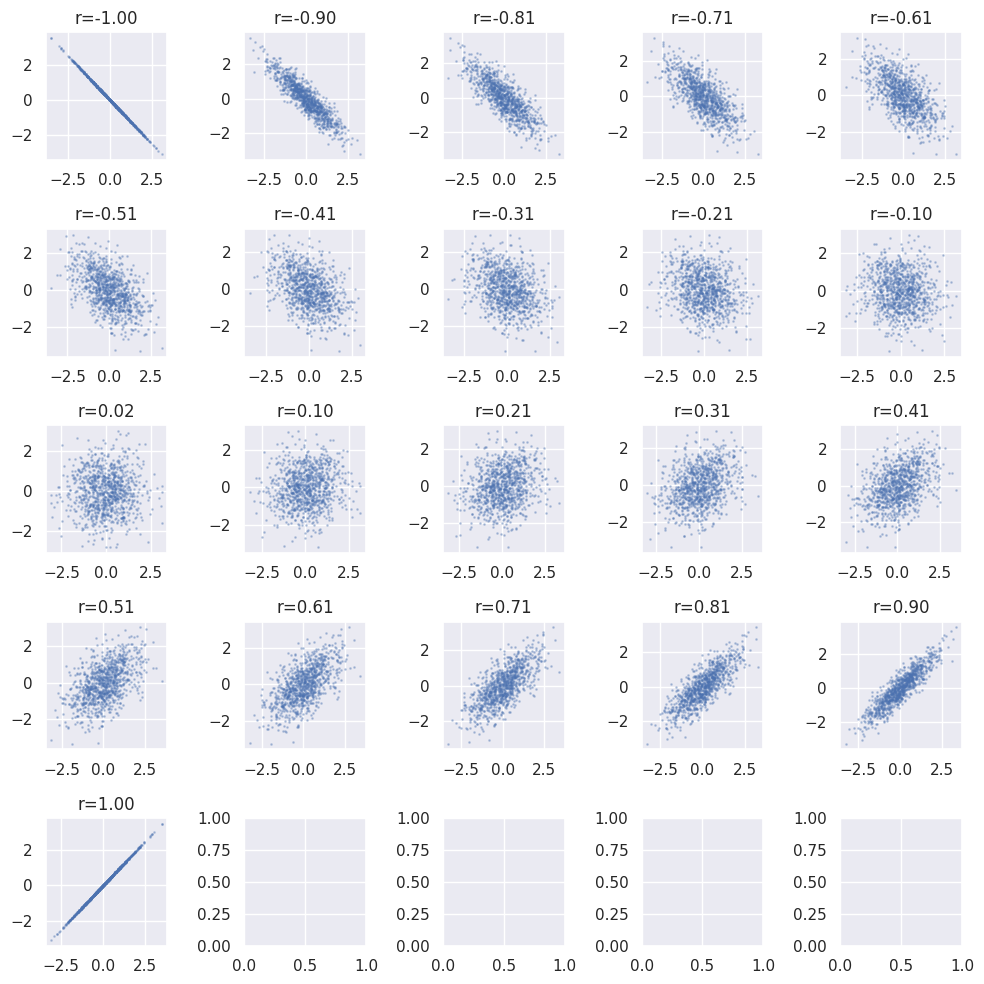

In [41]:
# subplotsのパラメータ
rows = 5
cols = 5
figsize = (10, 10)

fig, axes = plt.subplots(rows, cols, figsize=figsize)
for idx, r in enumerate(np.arange(-1, 1.1, 0.1)):
    row_i = idx // cols
    col_i = idx % cols

    x, y, actual_r = generate_values(r)

    axes[row_i, col_i].scatter(x, y, alpha=0.3, s=1)
    axes[row_i, col_i].set_title(f"r={actual_r:0.2f}")

fig.tight_layout()
plt.show()

### 外れ値

In [42]:
weight = np.array([42, 46, 53, 56, 58, 61, 62, 63, 65, 67, 73])
height = np.array([138, 150, 152, 163, 164, 167, 165, 182, 180, 180, 183])

#### 外れ値追加前

In [43]:
r = np.corrcoef(weight, height)[0, 1]
print(f"r={r:.2f} (before adding outelier)")

r=0.95 (before adding outelier)


#### 外れ値追加

In [44]:
weight = np.append(weight, 70)
height = np.append(height, 0)

In [45]:
r = np.corrcoef(weight, height)[0, 1]
print(f"r={r:.2f} (after adding outelier)")

r=-0.09 (after adding outelier)


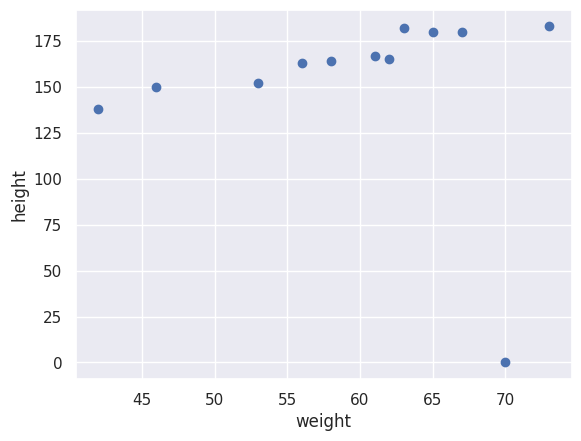

In [46]:
fig, axes = plt.subplots()
axes.scatter(weight, height)
axes.set_xlabel("weight")
axes.set_ylabel("height")
plt.show()

## 13 回帰分析を図でわかりやすく解説！条件付き平均と最小二乗法って？

[回帰分析を図でわかりやすく解説！条件付き平均と最小二乗法って？【統計学入門13】 - 米国データサイエンティストのブログ](https://datawokagaku.com/regression/)


In [47]:
weight = np.array([42, 46, 53, 56, 58, 61, 62, 63, 65, 67, 73])
height = np.array([138, 150, 152, 163, 164, 167, 165, 182, 180, 180, 183])

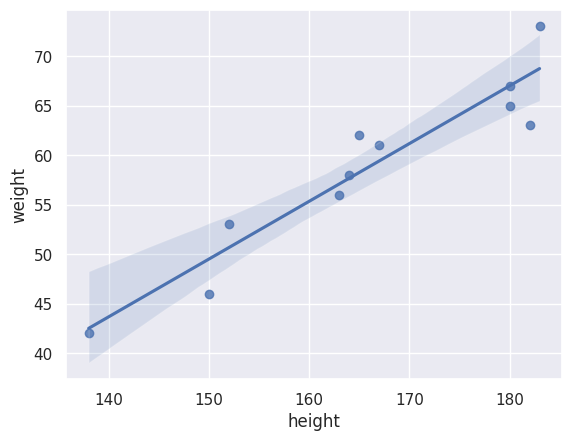

In [48]:
sns.set_theme()
fig, axes = plt.subplots()
sns.regplot(x=height, y=weight, ax=axes)
axes.set_xlabel("height")
axes.set_ylabel("weight")
plt.show()

In [49]:
df = pd.DataFrame({"weight": weight, "height": height})
df

,weight,height
0,42,138
1,46,150
2,53,152
3,56,163
4,58,164
5,61,167
6,62,165
7,63,182
8,65,180
9,67,180


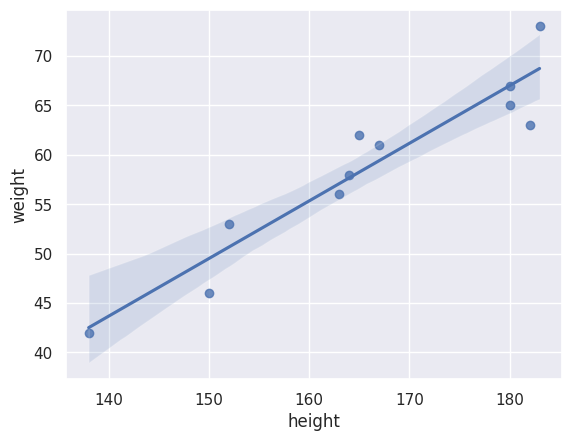

In [50]:
sns.set_theme()
fig, axes = plt.subplots()
sns.regplot(data=df, x="height", y="weight", ax=axes)
plt.show()

## 14 回帰直線の数式をイメージで理解する．回帰係数と相関係数の関係

[回帰直線の数式をイメージで理解する．回帰係数と相関係数の関係【統計学入門14】 - 米国データサイエンティストのブログ](https://datawokagaku.com/regression_python/)

- 最小2乗法
	- 正規方程式
- 回帰係数と相関係数の関係
- ライブラリの利用


### 最小2乗法

In [51]:
weight = np.array([42, 46, 53, 56, 58, 61, 62, 63, 65, 67, 73])
height = np.array([138, 150, 152, 163, 164, 167, 165, 182, 180, 180, 183])

回帰係数の計算1（共分散と分散）

In [52]:
S = np.cov(height, weight)
b = S[0, 1] / S[0, 0]
b

np.float64(0.583028590425532)

回帰係数の計算2（相関係数と標準偏差）

In [53]:
r = np.corrcoef(height, weight)[0, 1]
s_x = np.std(height)
s_y = np.std(weight)
b = r * s_y / s_x
b

np.float64(0.5830285904255318)

In [54]:
def my_linear_regression(x: np.ndarray, y: np.ndarray):
    S = np.cov(x, y)
    b = S[0, 1] / S[0, 0]
    a = np.mean(y) - b * np.mean(x)
    return (a, b)

In [55]:
my_linear_regression(height, weight)

(np.float64(-37.949468085106396), np.float64(0.583028590425532))

最小二乗法の計算結果を`sns.regplot()`の回帰直線と比較する。

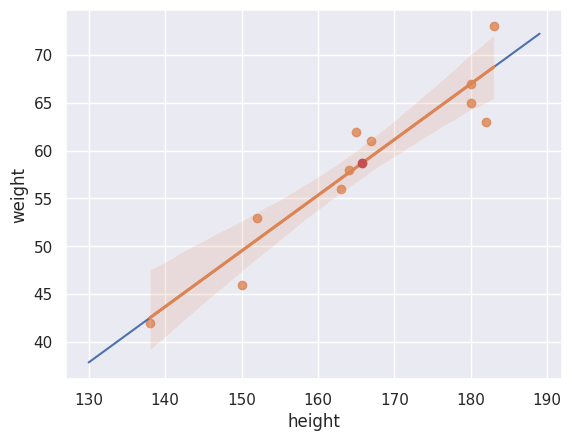

In [56]:
fig, axes = plt.subplots()

# 自前実装の回帰直線を描画
a, b = my_linear_regression(height, weight)
x = np.arange(130, 190, 1)
axes.plot(x, a + b * x)

# Seabornで散布図と回帰直線を描画
sns.regplot(x=height, y=weight, ax=axes)

# 平均に点
axes.plot(np.mean(height), np.mean(weight), "ro")

axes.set_xlabel("height")
axes.set_ylabel("weight")
plt.show()

### sklearn.linear_model.LinearRegression

In [57]:
from sklearn.linear_model import LinearRegression

# 説明変数: 軸を追加して行列にする
X = height[:, np.newaxis]
# 目的変数
y = weight

# インスタンス作成
reg = LinearRegression()

# 学習
reg.fit(X, y)

# 学習結果
print(f"b={reg.coef_}")
print(f"a={reg.intercept_}")

b=[0.58302859]
a=-37.94946808510644


In [58]:
X = np.array([[175]])
y = reg.predict(X)
print(X, y)

[[175]] [64.08053524]


## 15 回帰直線はyからxは予測できない??2通りの回帰直線

[回帰直線はyからxは予測できない??2通りの回帰直線【統計学入門15】 - 米国データサイエンティストのブログ](https://datawokagaku.com/lin_reg_xy/)


In [59]:
weight = np.array([42, 46, 53, 56, 58, 61, 62, 63, 65, 67, 73])
height = np.array([138, 150, 152, 163, 164, 167, 165, 182, 180, 180, 183])

`reg_weight`: `weight` の `height` への回帰

In [60]:
X = height[:, np.newaxis]
y = weight
reg_weight = LinearRegression()
reg_weight.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


`reg_height`: `height` の `weight` への回帰

In [61]:
X = weight[:, np.newaxis]
y = height
reg_height = LinearRegression()
reg_height.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


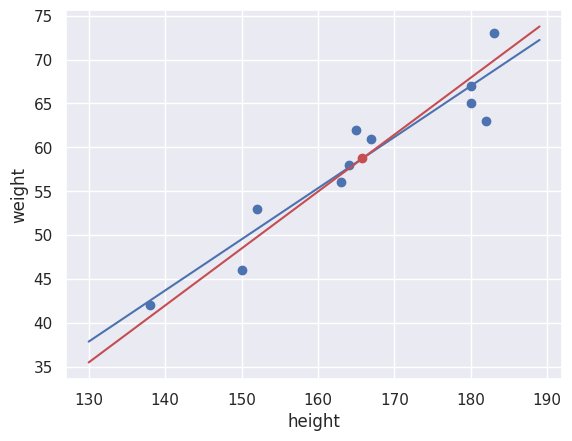

In [62]:
fig, axes = plt.subplots()
# 散布図
axes.scatter(height, weight)
# 直線を描画するためのx軸の値リストを作成
x = np.arange(130, 190, 1)
# weight の height への回帰
axes.plot(x, reg_weight.intercept_ + reg_weight.coef_ * x, "b")
# height の weight への回帰
axes.plot(x, (x - reg_height.intercept_) / reg_height.coef_, "r")
# 平均
axes.plot(np.mean(height), np.mean(weight), "ro")
axes.set_xlabel("height")
axes.set_ylabel("weight")
plt.show()

## 17 決定係数R2で回帰式の精度を評価する

[決定係数R2で回帰式の精度を評価する【統計学入門17】 - 米国データサイエンティストのブログ](https://datawokagaku.com/r_squared_howto/)


学習データで学習

In [63]:
weight = np.array([42, 46, 53, 56, 58, 61, 62, 63, 65, 67, 73])
height = np.array([138, 150, 152, 163, 164, 167, 165, 182, 180, 180, 183])

In [64]:
X = height[:, np.newaxis]
y = weight
reg = LinearRegression()
reg.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


評価データで予測値を計算

In [65]:
weight_test = np.array([43, 45, 50, 58, 58, 60, 66, 63, 65, 70, 72])
height_test = np.array([140, 148, 152, 163, 160, 170, 163, 177, 177, 185, 180])

In [66]:
X_test = height[:, np.newaxis]
y_test_pred = reg.predict(X_test)

散布図と回帰直線

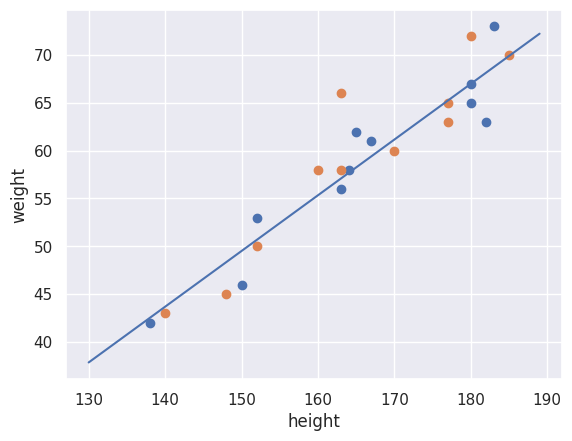

In [67]:
fig, axes = plt.subplots()
# 学習データ
axes.scatter(height, weight)
# 回帰直線
x = np.arange(130, 190, 1)
axes.plot(x, reg.intercept_ + reg.coef_ * x)
# 評価データ
axes.scatter(height_test, weight_test)
axes.set_xlabel("height")
axes.set_ylabel("weight")
plt.show()

決定係数を計算

In [68]:
def my_r2_score(y_true: np.ndarray, y_pred: np.ndarray):
    S_t = np.sum((y_true - np.mean(y_true)) ** 2)
    S_e = np.sum((y_true - y_pred) ** 2)
    return 1 - S_e / S_t

In [69]:
my_r2_score(weight_test, y_test_pred)

np.float64(0.8569626575763964)

In [70]:
from sklearn.metrics import r2_score

r2_score(weight_test, y_test_pred)

0.8569626575763964